In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [2]:
lego_set_data = pd.read_csv("lego_sets.csv")
lego_set_data

,ages,list_price,num_reviews,piece_count,play_star_rating,prod_desc,prod_id,prod_long_desc,review_difficulty,set_name,star_rating,theme_name,val_star_rating,country
0,6-12,29.9900,2.0,277.0,4.0,Catapult into action and take back the eggs fr...,75823.0,Use the staircase catapult to launch Red into ...,Average,Bird Island Egg Heist,4.5,Angry Birds™,4.0,US
1,6-12,19.9900,2.0,168.0,4.0,Launch a flying attack and rescue the eggs fro...,75822.0,Pilot Pig has taken off from Bird Island with ...,Easy,Piggy Plane Attack,5.0,Angry Birds™,4.0,US
2,6-12,12.9900,11.0,74.0,4.3,Chase the piggy with lightning-fast Chuck and ...,75821.0,Pitch speedy bird Chuck against the Piggy Car....,Easy,Piggy Car Escape,4.3,Angry Birds™,4.1,US
3,12+,99.9900,23.0,1032.0,3.6,Explore the architecture of the United States ...,21030.0,Discover the architectural secrets of the icon...,Average,United States Capitol Building,4.6,Architecture,4.3,US
4,12+,79.9900,14.0,744.0,3.2,Recreate the Solomon R. Guggenheim Museum® wit...,21035.0,Discover the architectural secrets of Frank Ll...,Challenging,Solomon R. Guggenheim Museum®,4.6,Architecture,4.1,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12256,7-14,36.5878,6.0,341.0,4.4,Protect NINJAGO® City from flying Manta Ray Bo...,70609.0,Help Cole save Shen-Li in this cool THE LEGO® ...,Easy,Manta Ray Bomber,4.3,THE LEGO® NINJAGO® MOVIE™,4.2,PT
12257,7-14,24.3878,8.0,217.0,4.1,Stop a Piranha Attack with Kai and Misako!,70629.0,Play out an action-packed Piranha Mech pursuit...,Easy,Piranha Attack,3.6,THE LEGO® NINJAGO® MOVIE™,4.1,PT
12258,7-14,24.3878,18.0,233.0,4.6,Stop a crime in the NINJAGO® City street market!,70607.0,"Team up with Lloyd Garmadon, Nya and Officer T...",Easy,NINJAGO® City Chase,4.6,THE LEGO® NINJAGO® MOVIE™,4.5,PT
12259,6-14,12.1878,1.0,48.0,5.0,Achieve Spinjitzu greatness with the Green Ninja!,70628.0,Learn all the skills of Spinjitzu with THE LEG...,Very Easy,Lloyd - Spinjitzu Master,5.0,THE LEGO® NINJAGO® MOVIE™,5.0,PT


In [3]:
lego_set_data.describe()

,list_price,num_reviews,piece_count,play_star_rating,prod_id,star_rating,val_star_rating
count,12261.000000,10641.000000,12261.000000,10486.000000,1.226100e+04,10641.000000,10466.000000
mean,65.141998,16.826238,493.405921,4.337641,5.983675e+04,4.514134,4.228960
std,91.980429,36.368984,825.364580,0.652051,1.638115e+05,0.518865,0.660282
min,2.272400,1.000000,1.000000,1.000000,6.300000e+02,1.800000,1.000000
25%,19.990000,2.000000,97.000000,4.000000,2.103400e+04,4.300000,4.000000
50%,36.587800,6.000000,216.000000,4.500000,4.206900e+04,4.700000,4.300000
75%,70.192200,13.000000,544.000000,4.800000,7.092200e+04,5.000000,4.700000
max,1104.870000,367.000000,7541.000000,5.000000,2.000431e+06,5.000000,5.000000


In [4]:
lego_set_data = lego_set_data.dropna()
list_price = lego_set_data["list_price"]
piece_count = lego_set_data["piece_count"]

In [5]:
#Calculates the linear regression between list price and piece count.
#Used to estimates the linear relationship betweenlist price and piece count.
linear_model = scipy.stats.linregress(list_price,piece_count)
slope = linear_model.slope
intercept = linear_model.intercept

linear_fit = slope*list_price+intercept

Correlation Coefficent: 0.9099714919716257


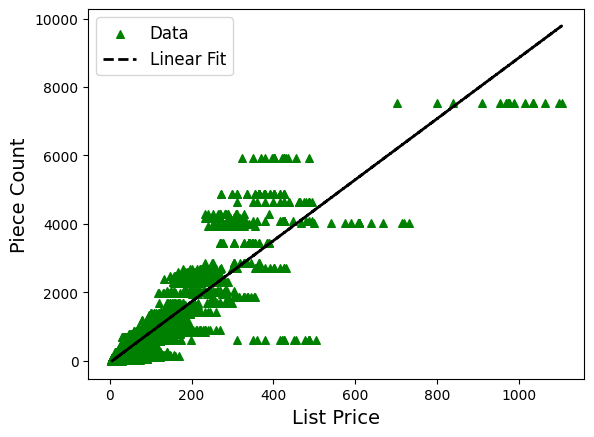

In [6]:
#Calculates the correlation coefficent between list price and piece count.
#Used to see if the relationship between list price and piece count is positive or negative.
corr = scipy.stats.pearsonr(list_price,piece_count)
correlation_coef = corr[0]
print("Correlation Coefficent:", correlation_coef)
#Plots the scatterplot of the relationship between list price and piece count.
#Used to visually show the relationship between  list price and piece count.
plt.scatter(list_price,piece_count,s=30, color="green", marker="^", label= "Data")
#Adds the linear fit line.
#Used to enhance the scatterplot.
plt.plot(list_price, linear_fit, linewidth=2, color="black", linestyle="--", label="Linear Fit")
#Adds legend and labels for x and y data frames.
#Used to enhance the scatterplot.
plt.xlabel("List Price", fontsize=14)
plt.ylabel("Piece Count", fontsize=14)
plt.legend(fontsize=12)

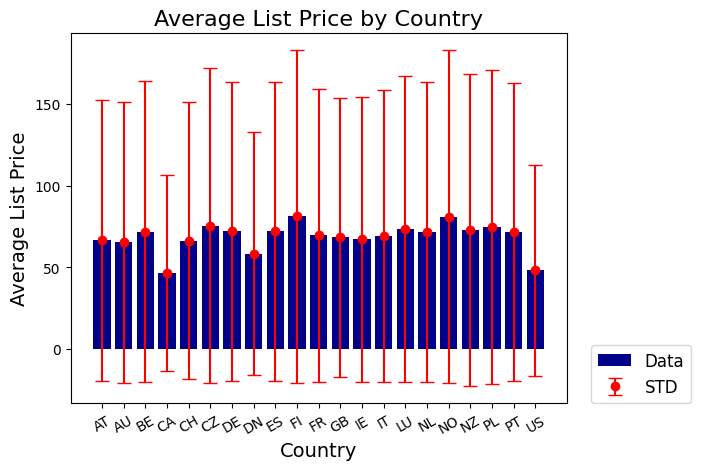

In [7]:
#Groups the country to the average list price
#Used to create a variable that will be used later
list_price_by_country = lego_set_data.groupby(by="country")["list_price"].mean()
#Groups the country to the standard deviation of the list price
#Used to create a variable that will be used later
list_price_by_country_std = lego_set_data.groupby(by="country")["list_price"].std()
#Creates a bar plot
#Used to visually how the relationship between the average list price and  country
plt.bar(list_price_by_country.index, list_price_by_country, color="darkblue", label="Data")
#Creates the error bars for the bar plot
#Used to show the level of error the bars had
plt.errorbar(list_price_by_country.index, list_price_by_country, list_price_by_country_std,\
             fmt="o", color="red", capsize=5, label="STD")

plt.xticks(rotation=30)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Average List Price", fontsize=14)
plt.title("Average List Price by Country", fontsize=16)
plt.legend(fontsize=12, loc=(1.05,0))

In [8]:
#Creates correlation scores
#Used to find the correlation between each data column
lego_set_data_corr = lego_set_data.corr(numeric_only=True)
lego_set_data_corr

,list_price,num_reviews,piece_count,play_star_rating,prod_id,star_rating,val_star_rating
list_price,1.000000,0.524727,0.909971,0.030636,0.065436,0.030599,-0.009959
num_reviews,0.524727,1.000000,0.571345,-0.027478,-0.108634,0.013210,0.024565
piece_count,0.909971,0.571345,1.000000,0.022434,0.030105,0.080949,0.077769
play_star_rating,0.030636,-0.027478,0.022434,1.000000,-0.006229,0.609693,0.504453
prod_id,0.065436,-0.108634,0.030105,-0.006229,1.000000,-0.076080,-0.069668
star_rating,0.030599,0.013210,0.080949,0.609693,-0.076080,1.000000,0.733314
val_star_rating,-0.009959,0.024565,0.077769,0.504453,-0.069668,0.733314,1.000000


In [9]:
#Creates a correlation matrix
#Visually shows the correlation between each data column
plt.matshow(lego_data_corr)
plt.colorbar()
plt.xlabel("Lego Properties")
plt.xticks(range(len(lego_data_corr.index)), lego_data_corr.index, rotation=90)
plt.yticks(range(len(lego_data_corr.index)), lego_data_corr.index)

NameError: name 'lego_data_corr' is not defined

In [ ]:
lego_set_data.describe()

In [ ]:
lego_set_data.info()

In [ ]:
Theme = ["BOOST","City","Classic","Architecture"]
Theme_sorted = []

for i in Theme:
    small_df = lego_set_data[lego_set_data["theme_name"]==i]
    Theme_sorted.append(small_df)

Theme_sorted

In [ ]:
Theme_merge = pd.concat([Theme_sorted[0], Theme_sorted[1], Theme_sorted[2], Theme_sorted[3]])
Theme_merge

In [ ]:
#summarize data by how many points fall into two different categories
#Used to find how many themes fall into certian difficulty types
theme_rev= pd.crosstab(Theme_merge["theme_name"], Theme_merge["review_difficulty"])

In [ ]:
#Calculate the p-value 
#Used to show if the theme name and review difficulty are dependent on eachother.
c, p, dof, expected = scipy.stats.chi2_contingency(theme_rev)
print(p)

dependant

Machine learning algorithm

In [ ]:
lego_set_data

Step 1: Data Preprocessing (Exploratory Data Analysis)

In [ ]:
lego_set_data.info()

In [ ]:
lego_set_data.nunique()

Step 2: Train-Test Split

In [ ]:
!pip install scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
#Drops all nan from columns.
#Used to clean up the dataframe.
lego_set_data = lego_set_data.dropna()
lego_set_data_cols = lego_set_data[["piece_count","num_reviews"]].dropna()

In [ ]:
#Creates a function
#Used to take the all the data from the list price column and converts it into a catagory
def list_price_to_categories (list_price):

    if list_price < 40:
        return 0 # This represents a low list price
    else:
        return 1 # This represents a high list price

In [ ]:
#Uses the map function
#Used to map the given function to every entry in the list_price column
lego_set_data['lego_data_categories'] = lego_set_data['list_price'].map(list_price_to_categories)

In [ ]:
#Separates the X data and the y data.
#Used to define an x and y data for later use in the program
X = lego_set_data_cols[["piece_count","num_reviews" ]]
y = lego_set_data["lego_data_categories"]
# Perform the train-test split
#Used to split the X and y data into a training set and a test set, both will be used in the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

Step 3: Train the Machine Learning Model

In [ ]:
# Defines the k-nearest neighbors classifier
#Used to show the number of neighbors is how many points the algorithm will look at near the test point to determine the class
classifier = KNeighborsClassifier(n_neighbors=3)
#Fit the algorithm with the training data
#Used to train the alorigthm
classifier.fit(X_train, y_train)

Step 4: Test the Model

In [ ]:
#Finds the predictions
#Used to create the predictions for the X_test
prediction = classifier.predict(X_test)
print(prediction[0:100])

Step 5: Evaluate its Performance

In [ ]:
#Creates a confusion matrix
#Shows how much of the predicted values were right vs how much were wrong. 
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)
#Find the accuracy score
#Used to see how acurate the predictions are
accuracy = accuracy_score(y_test, prediction)
print(accuracy*100)

Step 6: Improve the performance of the algorithm

In [ ]:
#Creates correlation scores
#Used to find the correlation between each data column
lego_set_data_corr = lego_set_data.corr(numeric_only=True)
lego_set_data_corr

In [ ]:
#Creates a correlation matrix
#Visually shows the correlation between each data column
plt.matshow(lego_data_corr)
plt.colorbar()
plt.xlabel("Lego Properties")
plt.xticks(range(len(lego_data_corr.index)), lego_data_corr.index, rotation=90)
plt.yticks(range(len(lego_data_corr.index)), lego_data_corr.index)

In [ ]:
# Separates the X data and the y data.
#Used to define an x and y data for later use in the program.
X = lego_set_data[["play_star_rating", "star_rating"]]
y = lego_set_data["lego_data_categories"]

# Perform the train-test split
#Used to split the X and y data into a training set and a test set, both will be used in the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

#Does hyperparameter tuning 
#Iterates over different values of k, the number of neighbors in the algorithm
k_value = []
accuracies = []

for k in range(1, 15, 1):
# Defines the k-nearest neighbors classifier
#Used to show the number of neighbors is how many points the algorithm will look at near the test point to determine the class
    classifier = KNeighborsClassifier(n_neighbors=k)
#Fit the algorithm with the training data
#Used to train the alorigthm
    classifier.fit(X_train, y_train)
#Finds the predictions
#Used to create the predictions for the X_test
    predictions = classifier.predict(X_test)
#Find the accuracy score
#Used to see how acurate the predictions are
    accuracy = accuracy_score(y_test, predictions)
    # Save the data to the appropriate lists
    #Used to append the k value and  appropriate lists to there appropriate lists
    k_value.append(k)
    accuracies.append(accuracy*100)

# Create a line plot
#Used to show accuracy versus the number of neighbors in the calculation
plt.plot(k_value, accuracies)
plt.xlabel("Number of Neighbors")
plt.ylabel("Percent Accuracy")

In [ ]:
# Defines the k-nearest neighbors classifier
#Used to show the number of neighbors is how many points the algorithm will look at near the test point to determine the class
classifier = KNeighborsClassifier(n_neighbors=3)
#Fit the algorithm with the training data
#Used to train the alorigthm
classifier.fit(X_train, y_train)
#Finds the predictions
#Used to create the predictions for the X_test
predictions = classifier.predict(X_test)
#Find the accuracy score
#Used to see how acurate the predictions are
accuracy = accuracy_score(y_test, predictions)
print(accuracy*100)
#Creates a confusion matrix
#Shows how much of the predicted values were right vs how much were wrong. 
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)